<div style="font-family:verdana;"><span style="font-size:400%;"> <center>Module 4: Density Estimation and KDE</center> </span>
    
</div>





# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">Contents</p>

**<a href=#1.-Introduction>1. Introduction</a>**

**<a href=#2.-What-is-a-density-estimation?>2. What is a density estimation?</a>**

**<a href=#3.-Histograms-as-crude-density-estimators>3. Histograms as crude density estimators</a>**

**<a href=#4.-Kernel-density-estimation>4. Kernel density estimation</a>**

**<a href=#5.-The-bandwidth-tradeoff>5. The bandwidth tradeoff</a>**

**<a href=#6.-Comparing-the-manual-implementation-to-a-library-implementation>6. Comparing the manual implementation to a library implementation</a>**

**<a href=#7.-Optional-boundary-bias-example>7. Optional boundary-bias example</a>**

**<a href=#8.-Strengths-and-limitations-of-KDE>8. Strengths and limitations of KDE</a>**

**<a href=#9.-Takeaways>9. Takeaways</a>**

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">1. Introduction</p>

This notebook introduces nonparametric density estimation, with a focus on histograms and kernel density estimation (KDE).

The main goals are:

1. understand what a density estimate is trying to recover,
2. see why histograms are crude density estimators,
3. implement a Gaussian KDE manually,
4. understand the role of bandwidth in smoothing,
5. compare a manual KDE with a library implementation.

This module is an important transition in the repo. Earlier modules focused mainly on nonparametric inference for statistics and tests. Here the focus shifts toward nonparametric estimation of an unknown function.

## 📙 Import libraries and modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from scipy import stats

from nonparametric_stats.kde import (
    gaussian_kde_manual,
    silverman_bandwidth,
    approximate_integral,
)

## ⚙️ Configuration

In [2]:
rng = np.random.default_rng(42)

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">2. What is a density estimation?</p>

A density function describes how probability mass is distributed over a continuous variable.

In practice, the true density is usually unknown. Density estimation is the problem of using sample data to reconstruct that unknown shape.

### Why this matters

Density estimation is one of the clearest examples of nonparametric modeling. Instead of assuming that the data come from a normal distribution or some other fixed parametric family, we try to estimate the density directly from the sample.

### Two basic approaches

Two common approaches are:

- the **histogram**, which groups observations into bins,
- **kernel density estimation (KDE)**, which smooths each observation into a local bump and adds those bumps together.

The histogram is simple and intuitive, but its appearance can change sharply with the bin choice. KDE usually produces a smoother and often more interpretable estimate, but it introduces an important tuning parameter: the bandwidth.

In [3]:
x = np.concatenate([
    rng.normal(-2.0, 0.7, 300),
    rng.normal(1.5, 0.5, 200),
])

sample_summary = pd.DataFrame({
    "quantity": ["n", "sample mean", "sample median", "sample std"],
    "value": [len(x), np.mean(x), np.median(x), np.std(x, ddof=1)],
})

sample_summary.round(4)

,quantity,value
0,n,500.0000
1,sample mean,-0.6115
2,sample median,-1.4300
3,sample std,1.8367


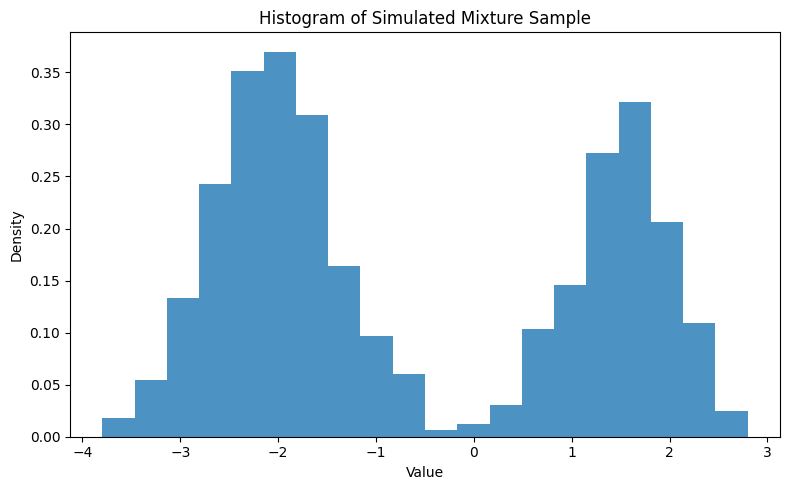

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(x, bins=20, density=True, alpha=0.8)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram of Simulated Mixture Sample")
plt.tight_layout()
plt.savefig("../reports/figures/kde_histogram_mixture.png", dpi=150, bbox_inches="tight")
plt.show()

The sample appears to come from a multimodal distribution. This is exactly the kind of setting where rigid parametric assumptions can become misleading and nonparametric density estimation becomes attractive.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">3. Histograms as crude density estimators</p>

A histogram is often the first density-like summary students see. But it is useful to understand that a histogram is itself a nonparametric estimator, and that its behavior depends strongly on the chosen number of bins.

This means that even very simple nonparametric estimators involve tuning choices.

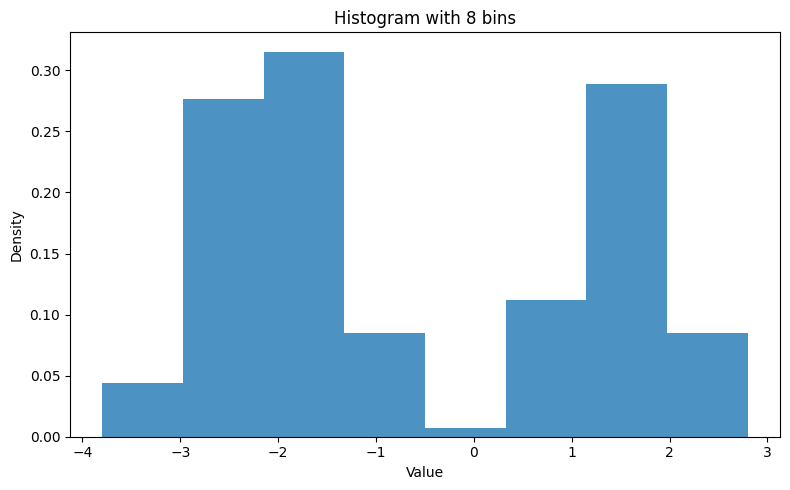

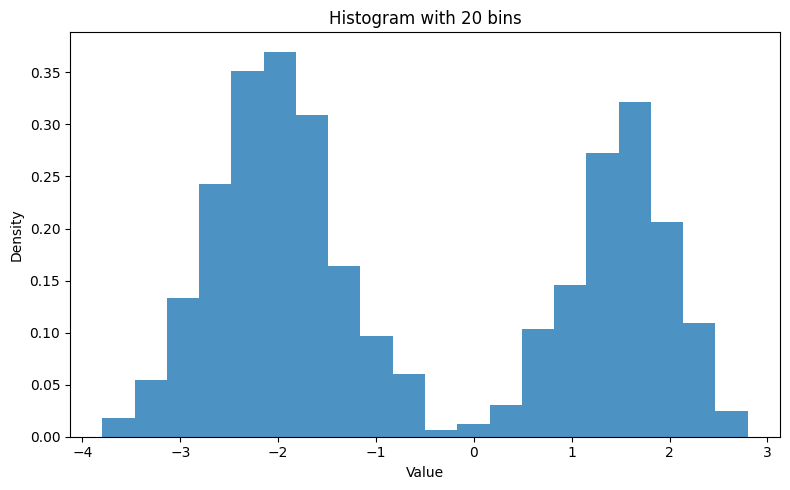

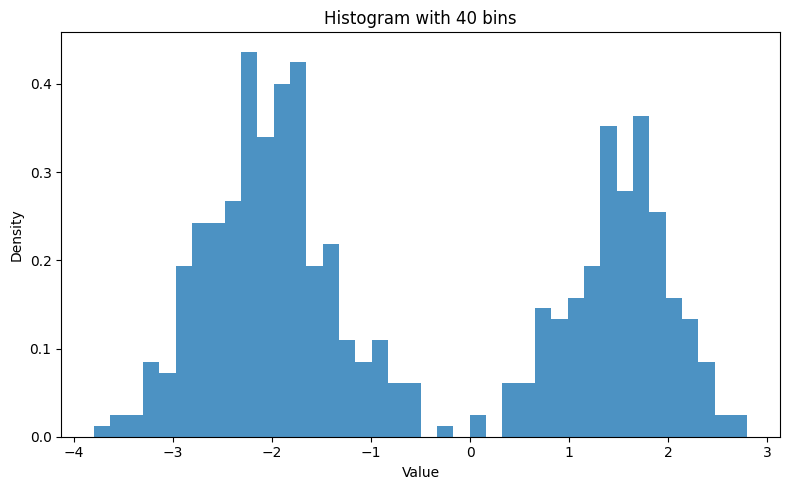

In [5]:
for bins in [8, 20, 40]:
    plt.figure(figsize=(8, 5))
    plt.hist(x, bins=bins, density=True, alpha=0.8)
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title(f"Histogram with {bins} bins")
    plt.tight_layout()
    plt.savefig(f"../reports/figures/kde_hist_{bins}_bins.png", dpi=150, bbox_inches="tight")
    plt.show()

The apparent shape of the distribution changes noticeably as the number of bins changes. This is one reason histograms can be unstable as density estimators: small design choices can strongly affect the visual impression.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">4. Kernel density estimation</p>

Kernel density estimation smooths the data by placing a small kernel bump at each observation and summing those bumps.

In one dimension, the KDE can be written as

$$
\hat{f}_h(t) = \frac{1}{nh} \sum_{i=1}^n K\left(\frac{t - x_i}{h}\right),
$$

where:

- $K$ is the kernel function,
- $h$ is the bandwidth,
- $x_1, \dots, x_n$ are the observed data.

### The crucial role of bandwidth

The bandwidth $h$ controls the amount of smoothing:

- small $h$: rough, highly variable estimate,
- large $h$: smooth, but possibly oversmoothed estimate.

In practice, bandwidth matters much more than the exact kernel choice.

In [6]:
grid = np.linspace(x.min() - 2, x.max() + 2, 500)
bw_silverman = silverman_bandwidth(x)
kde_manual = gaussian_kde_manual(x, grid, bandwidth=bw_silverman)

kde_summary = pd.DataFrame({
    "quantity": ["Silverman bandwidth", "Approximate integral of KDE"],
    "value": [bw_silverman, approximate_integral(grid, kde_manual)],
})

kde_summary.round(4)

,quantity,value
0,Silverman bandwidth,0.477
1,Approximate integral of KDE,1.000


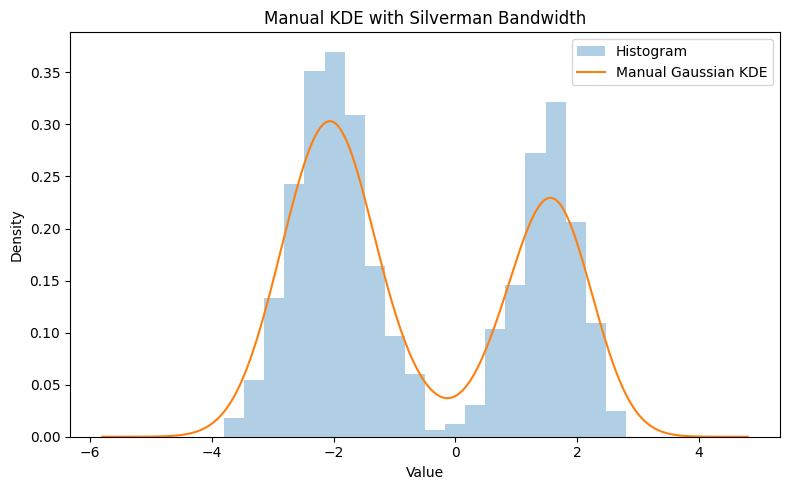

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(x, bins=20, density=True, alpha=0.35, label="Histogram")
plt.plot(grid, kde_manual, label="Manual Gaussian KDE")
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Manual KDE with Silverman Bandwidth")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/kde_manual_silverman.png", dpi=150, bbox_inches="tight")
plt.show()

The KDE produces a smoother estimate than the histogram while still preserving the broad multimodal structure of the sample.

The integral is close to 1, which is what we expect from a density estimate.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">5. The bandwidth tradeoff</p>

The bandwidth is the most important tuning parameter in KDE.

To see this clearly, we compare several bandwidth values. This illustrates one of the defining tradeoffs in nonparametric estimation: the balance between roughness and smoothness, or more formally, variance and bias.

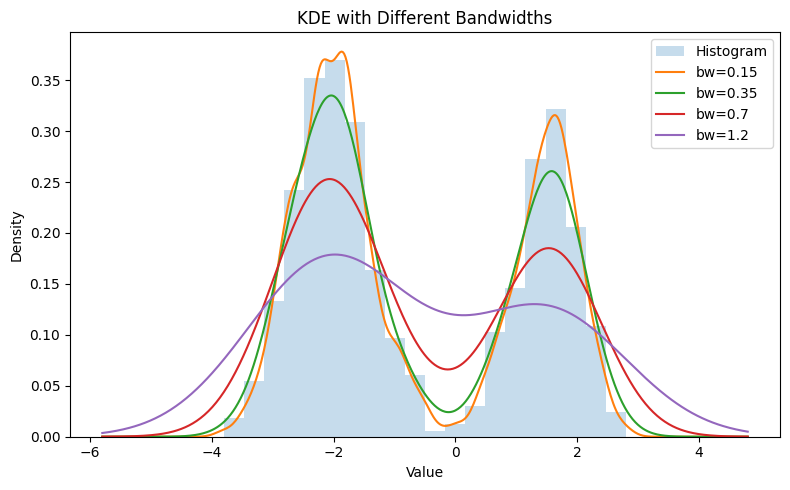

In [8]:
bandwidths = [0.15, 0.35, 0.7, 1.2]

plt.figure(figsize=(8, 5))
plt.hist(x, bins=20, density=True, alpha=0.25, label="Histogram")

for bw in bandwidths:
    vals = gaussian_kde_manual(x, grid, bandwidth=bw)
    plt.plot(grid, vals, label=f"bw={bw}")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("KDE with Different Bandwidths")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/kde_bandwidth_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

The smallest bandwidth produces a rough, wiggly estimate that tracks local noise closely. The largest bandwidth produces a very smooth estimate but risks obscuring important structure.

This is the classic bias-variance tradeoff in a highly visual form.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">6. Comparing the manual implementation to a library implementation</p>

A good practice in this repo is to implement methods manually where reasonable and then validate them against standard libraries.

In [9]:
kde_sklearn = KernelDensity(kernel="gaussian", bandwidth=bw_silverman)
kde_sklearn.fit(x[:, None])

log_dens = kde_sklearn.score_samples(grid[:, None])
dens_sklearn = np.exp(log_dens)

comparison_summary = pd.DataFrame({
    "quantity": [
        "Manual KDE integral",
        "sklearn KDE integral",
        "Max absolute difference",
    ],
    "value": [
        approximate_integral(grid, kde_manual),
        approximate_integral(grid, dens_sklearn),
        np.max(np.abs(kde_manual - dens_sklearn)),
    ],
})

comparison_summary.round(6)

,quantity,value
0,Manual KDE integral,1.0
1,sklearn KDE integral,1.0
2,Max absolute difference,0.0


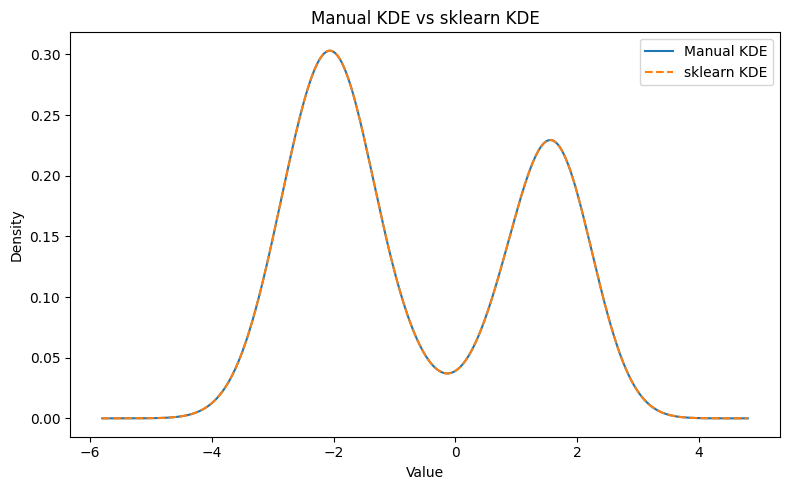

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(grid, kde_manual, label="Manual KDE")
plt.plot(grid, dens_sklearn, linestyle="--", label="sklearn KDE")
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Manual KDE vs sklearn KDE")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/kde_manual_vs_sklearn.png", dpi=150, bbox_inches="tight")
plt.show()

The two estimates should be very close. This confirms that the manual implementation is behaving as expected and reinforces the value of validating custom code against trusted libraries.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">7. Optional boundary-bias example</p>

KDE can behave poorly near boundaries, especially when the true support of the data is restricted.

To illustrate this, consider exponential data, which live on $[0, \infty)$. A standard Gaussian KDE will smooth some mass into the negative region, even though the true density is zero there.

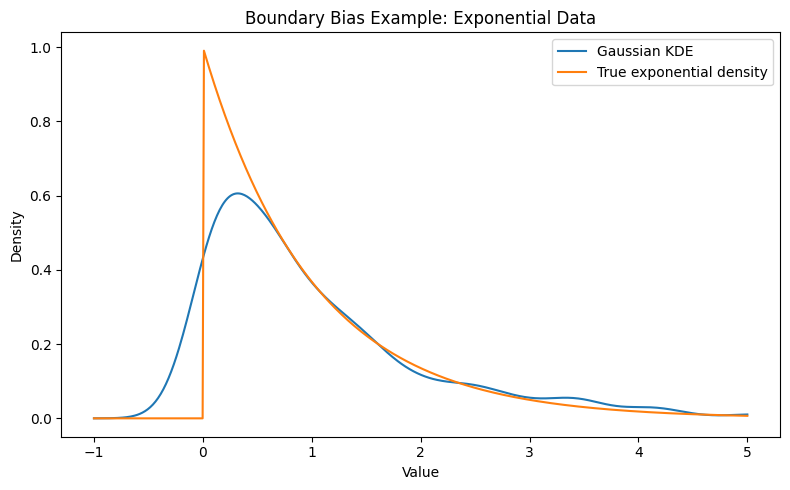

In [11]:
x_exp = rng.exponential(scale=1.0, size=300)
grid_exp = np.linspace(-1.0, 5.0, 500)
bw_exp = silverman_bandwidth(x_exp)

kde_exp = gaussian_kde_manual(x_exp, grid_exp, bandwidth=bw_exp)
true_exp = stats.expon.pdf(grid_exp, scale=1.0)

plt.figure(figsize=(8, 5))
plt.plot(grid_exp, kde_exp, label="Gaussian KDE")
plt.plot(grid_exp, true_exp, label="True exponential density")
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Boundary Bias Example: Exponential Data")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/kde_boundary_bias_exponential.png", dpi=150, bbox_inches="tight")
plt.show()

The KDE places positive density to the left of zero because the Gaussian kernel is symmetric and does not respect the boundary of the support.

This is a useful reminder that nonparametric methods are flexible, but they still have structural weaknesses and edge cases.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">8. Strengths and limitations of KDE</p>

**Strengths**
- flexible, smooth estimate of an unknown density,
- avoids committing to a fixed parametric family,
- often more informative than a histogram,
- makes the bias-variance tradeoff highly visible.

**Limitations**
- highly sensitive to bandwidth choice,
- can struggle near boundaries,
- becomes harder in higher dimensions,
- does not automatically solve the problem of interpretation.

KDE is best understood as a powerful smoothing tool, not as a push-button replacement for substantive modeling judgment.

In [12]:
final_summary = pd.DataFrame({
    "concept": [
        "Histogram",
        "Kernel density estimator",
        "Bandwidth",
        "Boundary bias",
    ],
    "meaning": [
        "A crude nonparametric density estimator based on bins",
        "A smooth nonparametric density estimator",
        "Controls the amount of smoothing",
        "Distortion near the edge of the support",
    ],
})

final_summary

,concept,meaning
0,Histogram,A crude nonparametric density estimator based ...
1,Kernel density estimator,A smooth nonparametric density estimator
2,Bandwidth,Controls the amount of smoothing
3,Boundary bias,Distortion near the edge of the support


# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">9. Takeaways</p>

This notebook introduced nonparametric density estimation through histograms and KDE.

- Histograms are simple but sensitive to bin choice.
- KDE provides a smoother estimate of an unknown density.
- Bandwidth is the key tuning parameter and controls the roughness-smoothness tradeoff.
- Nonparametric estimators are flexible, but they still require judgment and can fail in structured ways, such as at boundaries.

The broader lesson is that nonparametric modeling often replaces rigid functional-form assumptions with local smoothing and tuning choices.